# Team 14 Supervised Learning

#### Group Members: Ernest Ceballos, Júlia Galimany, Oriol Galimany, Iván Pérez, Nerea Salvador

## Task 1. Data loading and exploration

**Libraries**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

**Information of the dataset**

In [48]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.keys()

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

When we load the dataset with `load_breast_cancer()`, scikit-learn gives us a Bunch object where the features and the target labels are already kept in separate arrays. To make things easier during the first part of the project, we manually add the labels to our DataFrame using `df['target'] = data.target`.

In [49]:
df['target'] = data.target 

In [50]:
print(f"Shape of the dataset: {df.shape}")
print(f"Data types:\n{df.dtypes}")

Shape of the dataset: (569, 31)
Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst conca

In [51]:
#We check for missing values in the dataset
print(f"Number of missing values: {df.isna().sum().sum()}")

Number of missing values: 0


In [52]:
print(f"Summary statistics:\n{df.describe()}")

Summary statistics:
       mean radius  mean texture  ...  worst fractal dimension      target
count   569.000000    569.000000  ...               569.000000  569.000000
mean     14.127292     19.289649  ...                 0.083946    0.627417
std       3.524049      4.301036  ...                 0.018061    0.483918
min       6.981000      9.710000  ...                 0.055040    0.000000
25%      11.700000     16.170000  ...                 0.071460    0.000000
50%      13.370000     18.840000  ...                 0.080040    1.000000
75%      15.780000     21.800000  ...                 0.092080    1.000000
max      28.110000     39.280000  ...                 0.207500    1.000000

[8 rows x 31 columns]


**Class balance**

In [53]:
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100 

print(f"Malignant (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Benign (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

Malignant (0): 212 (37.26%)
Benign (1): 357 (62.74%)


The dataset is **moderately imbalanced**, with a higher proportion of benign cases (62.74%) compared to malignant cases (37.26%). While the imbalance is not extreme, it should be taken into account when evaluating model performance, as it may bias the classifier towards the majority class.

**Plots**

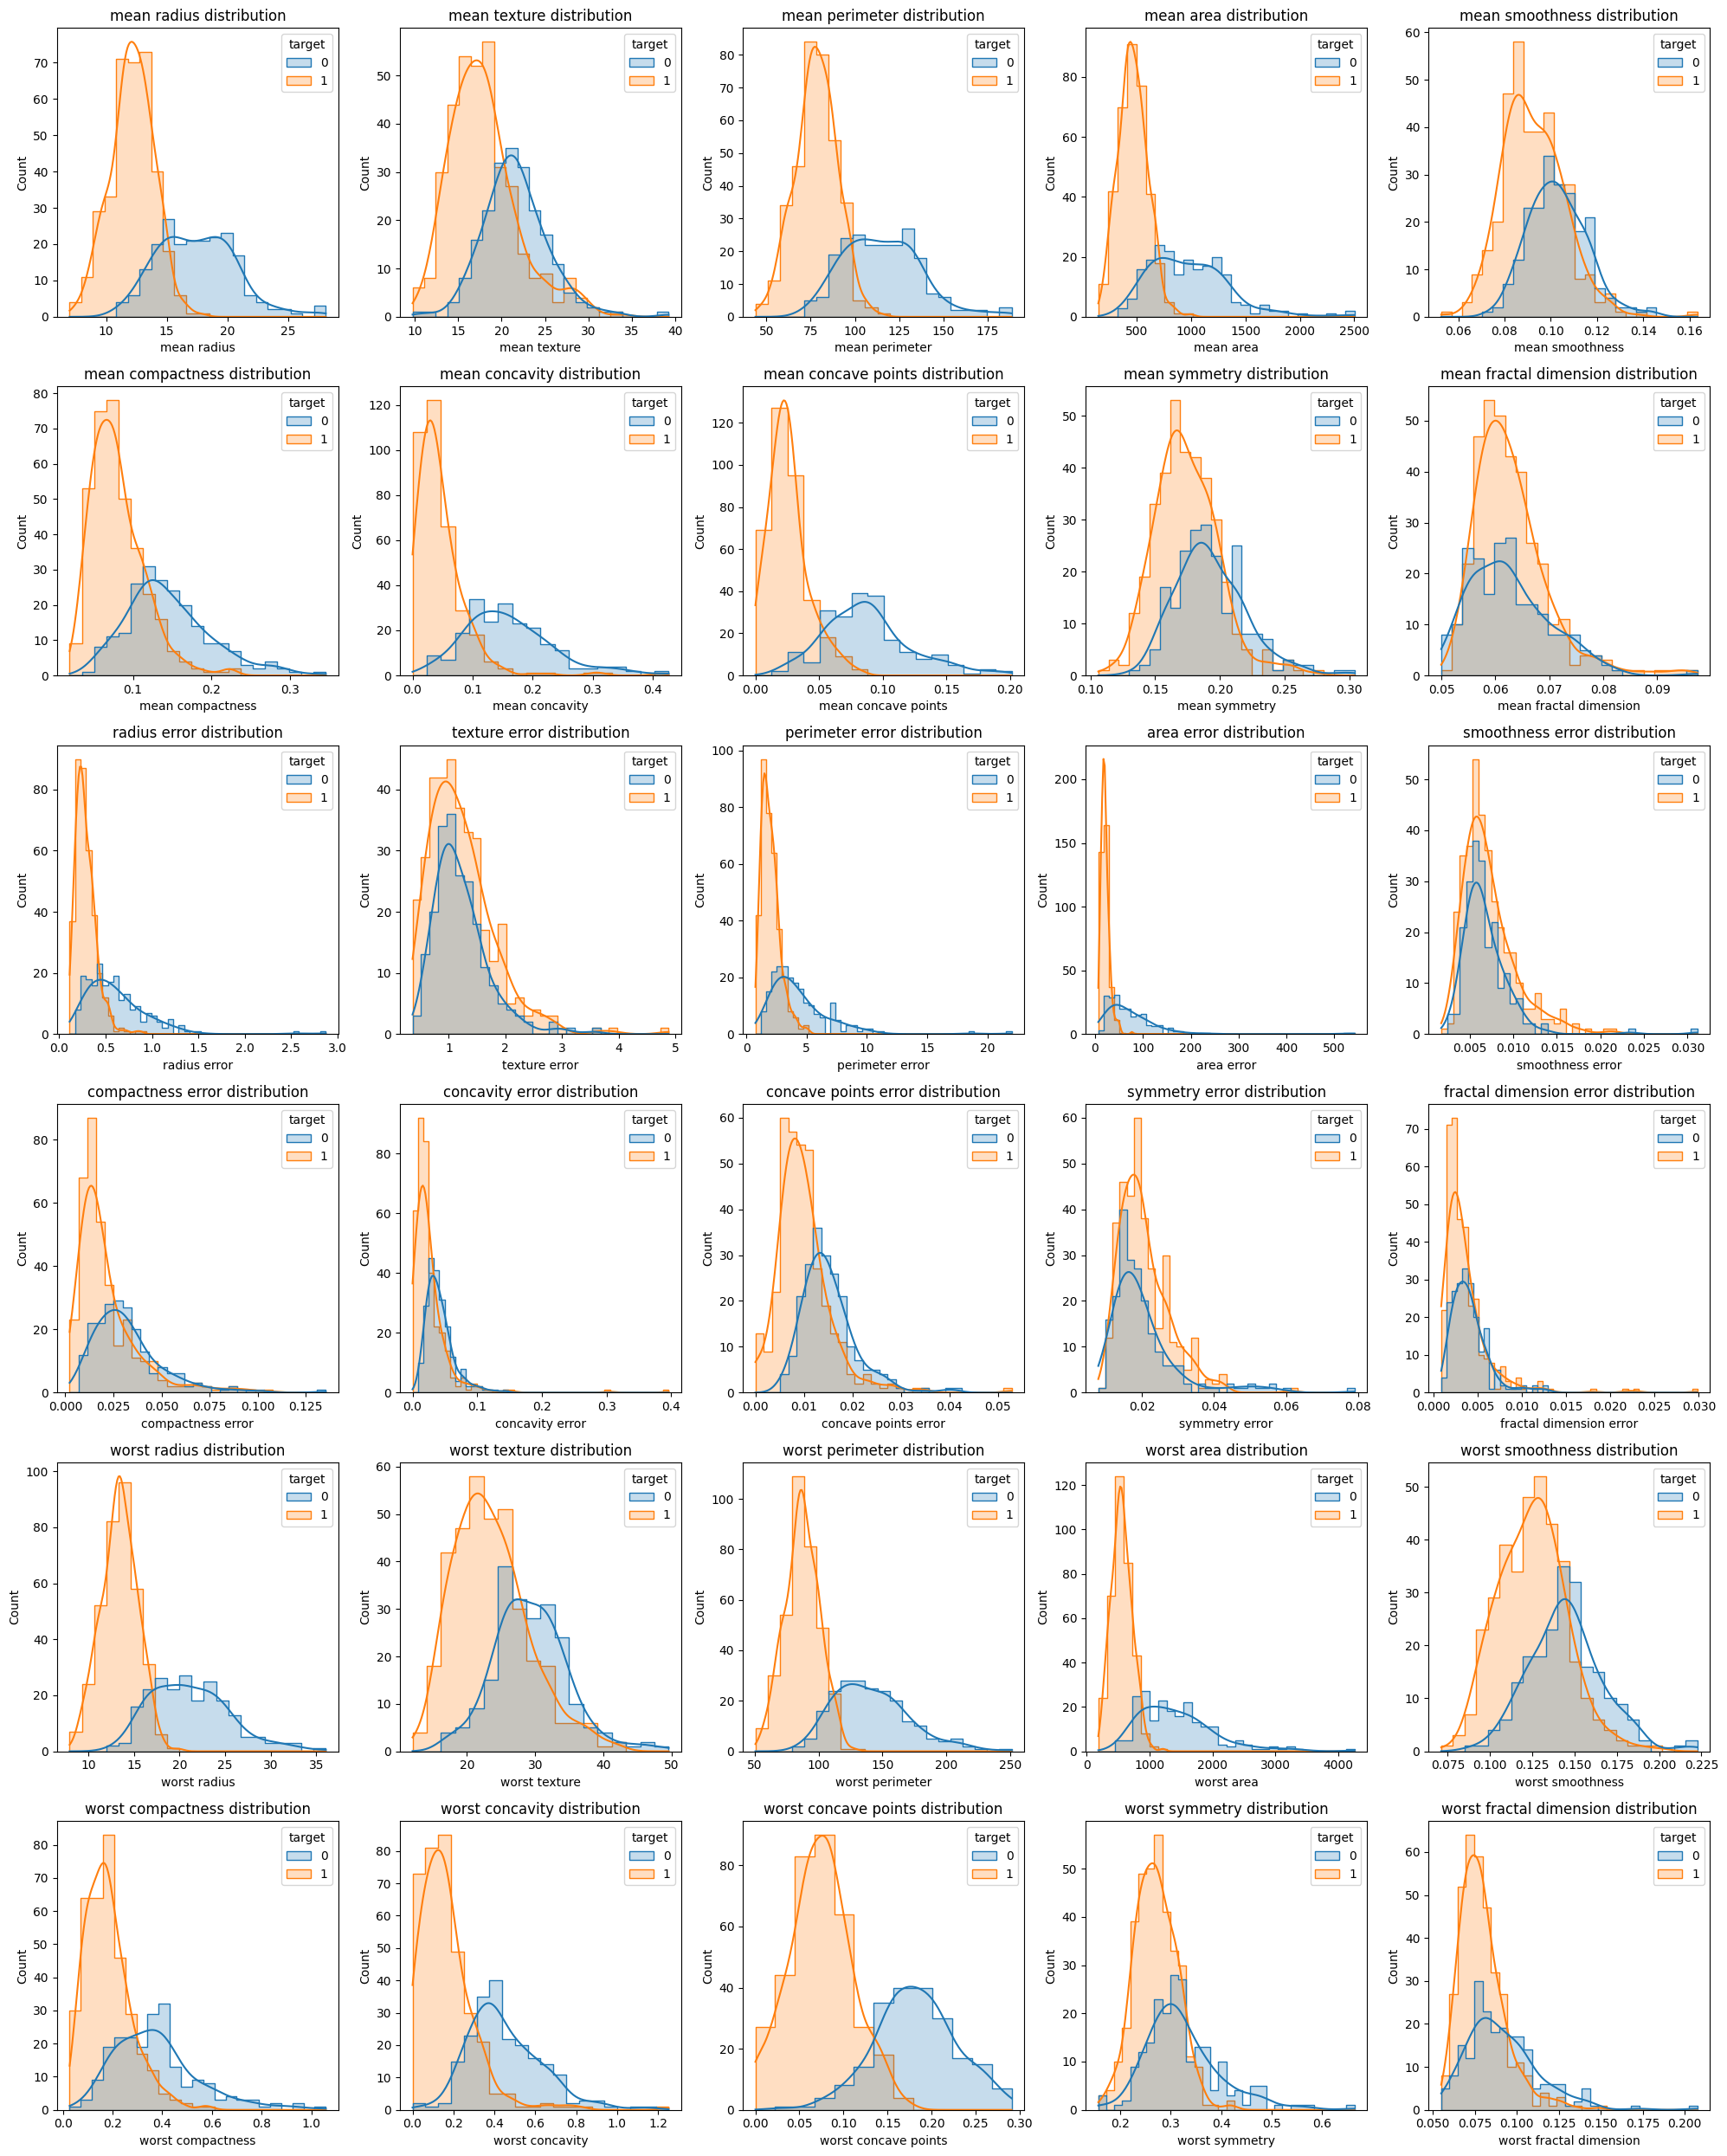

In [54]:
features = data.feature_names
plt.figure(figsize=(20, 25))

for i, feature in enumerate(features):
    plt.subplot(6, 5, i + 1)
    sns.histplot(data=df, x=feature, hue='target', kde=True, element="step")
    plt.title(f'{feature} distribution')

plt.tight_layout()
plt.show()

An initial inspection of the feature distributions reveals that several variables act as strong discriminators between malignant and benign cases. Specifically, **mean radius**, **mean perimeter**, **mean area**, **mean concavity** and **mean concave points**, along with their "worst" counterparts, exhibit the most significant separation between classes. The limited overlap observed in these distributions suggests that these features are highly informative for identifying malignant tumours.

At the same time, the distributions of radius, perimeter, and area appear very similar, indicating a high degree of multicollinearity. Since all three features capture related aspects of tumour size, they are likely to provide redundant information to the model. Additionally, concavity features display a separation pattern similar to concave points, further highlighting their relevance for the classification task.

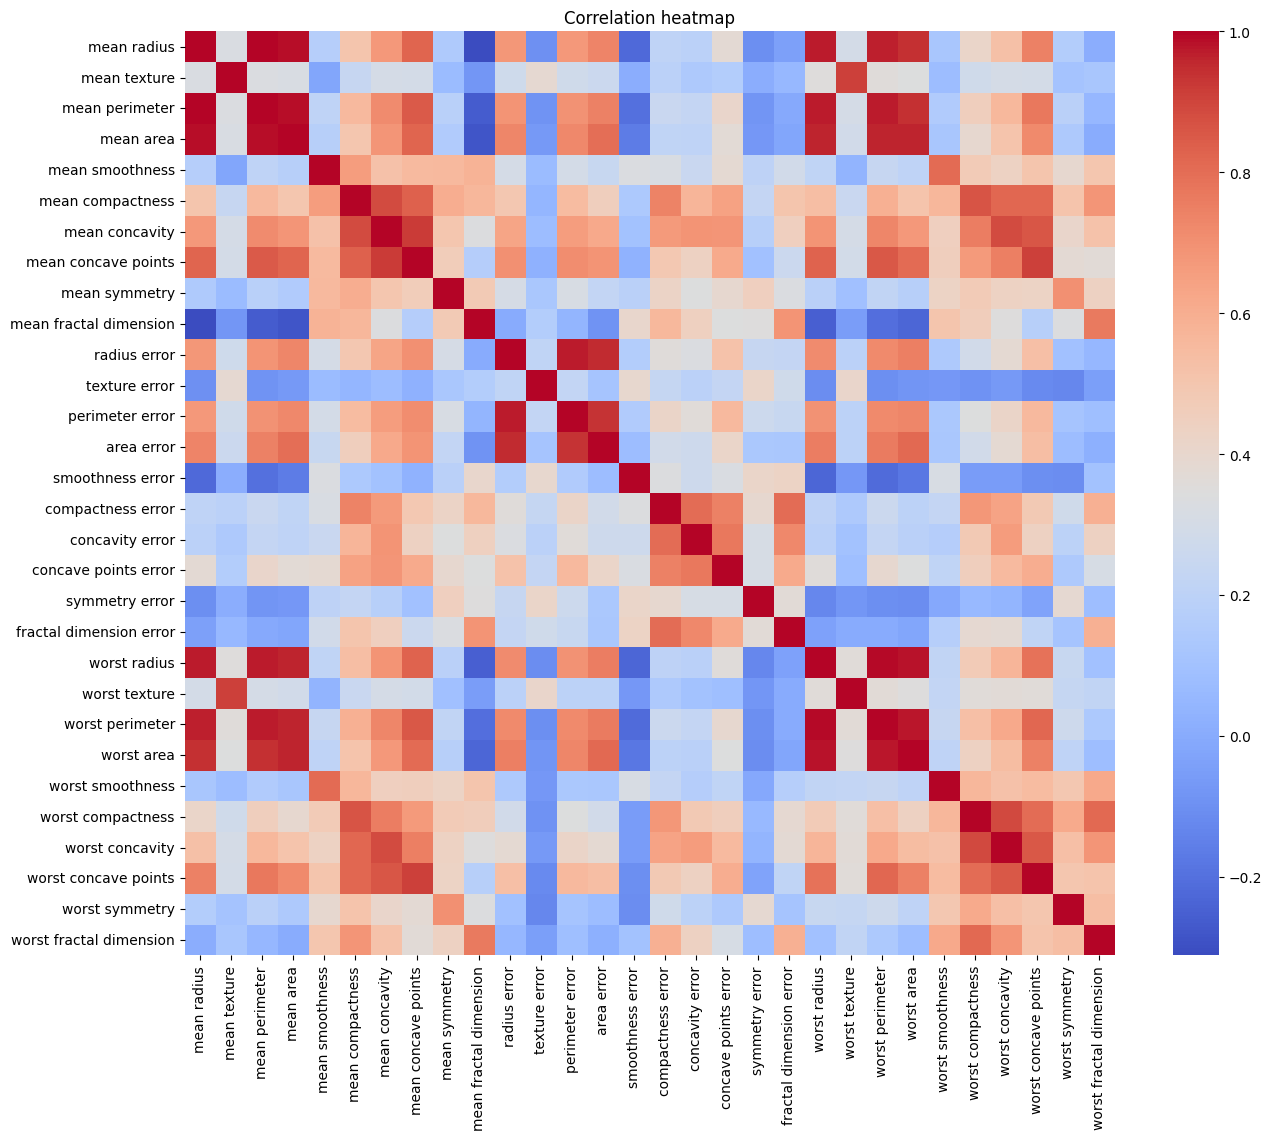

Top correlated pairs:
mean radius      mean perimeter         0.997855
worst radius     worst perimeter        0.993708
mean radius      mean area              0.987357
mean perimeter   mean area              0.986507
worst radius     worst area             0.984015
worst perimeter  worst area             0.977578
radius error     perimeter error        0.972794
mean perimeter   worst perimeter        0.970387
mean radius      worst radius           0.969539
mean perimeter   worst radius           0.969476
mean radius      worst perimeter        0.965137
mean area        worst radius           0.962746
                 worst area             0.959213
                 worst perimeter        0.959120
radius error     area error             0.951830
mean perimeter   worst area             0.941550
mean radius      worst area             0.941082
perimeter error  area error             0.937655
mean concavity   mean concave points    0.921391
mean texture     worst texture          0.91204

In [55]:
plt.figure(figsize=(15, 12))
corr_matrix = df.drop('target', axis=1).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

# Find the most correlated pairs of features
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
print("Top correlated pairs:")
print(pairs.head(20))

The correlation heatmap and the numerical ranking of top-correlated pairs strongly corroborate the visual patterns observed in the histograms. The extreme multicollinearity is mathematically confirmed by pairs such as **mean radius** and **mean perimeter** (r = 0.998), and **worst radius** and **worst perimeter** (r = 0.994), which directly explains why their respective histograms share nearly identical distributions. This alignment confirms that these features are geometrically redundant, as they all measure different aspects of tumor size. Beyond size, the high correlation between **mean concavity and mean concave points** (r = 0.921) confirms the overlapping distribution patterns seen for these shape-related variables. 

The data also reveals important relationships that were less obvious in the individual plots, such as the strong link between "mean" and "worst" measurements (e.g., **mean texture and worst texture** at r = 0.912), indicating that patients with high average values consistently exhibit high peak values as well. Furthermore, the high correlation between **radius error and perimeter error** (r = 0.973) suggests that the variance in measurement is also uniform across size-related metrics.

## Task 2: Preprocessing and feature analysis

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Split the data**

In [57]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [58]:
# We check the distribution of classes in the training and test sets to ensure they are balanced
print(f"Train: {len(X_train)} (Malignant: {sum(y_train==0)}, Benign: {sum(y_train==1)})")
print(f"Test: {len(X_test)} (Malignant: {sum(y_test==0)}, Benign: {sum(y_test==1)})")

Train: 455 (Malignant: 170, Benign: 285)
Test: 114 (Malignant: 42, Benign: 72)


**StandardScaler**

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # We fit the scaler only on the training set to avoid data leakage
X_test_scaled = scaler.transform(X_test) # We transform the test data using the fitted scaler
# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,-0.743949,-0.629805,0.000748,-0.991573,-0.693760,-0.983284,-0.591579,-0.428972,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,0.094075,0.317524,0.639656,0.087389,0.708451,1.182150,0.426212,0.074797,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,-0.338634,-0.413827,0.520240,-0.833114,-1.006736,-1.857894,1.356046,-1.006560,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,-0.411682,-0.436600,-0.393580,-0.129997,-0.219965,-0.527278,-0.269450,-0.316623,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,-0.440597,-0.521457,-0.174225,-0.628196,-0.581187,-0.278344,1.528534,-0.313022,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


**Correlation**

In [60]:
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # We use the upper triangle of the correlation matrix to avoid duplicate pairs and self-correlation

correlation_threshold = 0.95 # We use a correlation threshold of 0.95 to identify highly redundant predictors

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"] > correlation_threshold
].sort_values(by="Correlation", ascending=False)

high_corr_pairs

,Feature 1,Feature 2,Correlation
2,mean radius,mean perimeter,0.997789
622,worst radius,worst perimeter,0.993478
3,mean radius,mean area,0.988886
63,mean perimeter,mean area,0.987834
623,worst radius,worst area,0.985890
683,worst perimeter,worst area,0.978738
82,mean perimeter,worst perimeter,0.970918
312,radius error,perimeter error,0.970870
20,mean radius,worst radius,0.970133
80,mean perimeter,worst radius,0.969674


In [61]:
features_to_drop = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

features_to_drop

['mean perimeter',
 'mean area',
 'perimeter error',
 'area error',
 'worst radius',
 'worst perimeter',
 'worst area']

In [62]:
X_train_reduced = X_train_scaled.drop(columns=features_to_drop)
X_test_reduced = X_test_scaled.drop(columns=features_to_drop)
print("Original number of features:", X_train.shape[1])
print("Reduced number of features after scaling:", X_train_reduced.shape[1])
print("Dropped features:", features_to_drop)

Original number of features: 30
Reduced number of features after scaling: 23
Dropped features: ['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']


Based on the correlation analysis, seven features were removed from the dataset: `mean perimeter`, `mean area`, `perimeter error`, `area error`, `worst radius`, `worst perimeter`, and `worst area`. These variables were not removed because they were irrelevant, but because they were highly redundant with other features already present in the dataset.

This decision is consistent with the results observed in Task 1. The histograms showed that several size-related variables, such as `mean radius`, `mean perimeter`, and `mean area`, had very similar distribution patterns and separated malignant and benign cases in a comparable way. This suggested that these features were capturing closely related information about tumour size.

The correlation heatmap confirmed very strong correlations between geometrically related variables, especially radius, perimeter, and area measurements, including their “worst” and error versions. This is expected because larger nuclei tend to have larger radii, perimeters, and areas, so keeping all these variables would introduce redundant information into the models. For this reason, the most correlated and redundant features were removed.

Overall, the feature reduction was based on both visual evidence from the histograms and the correlation analysis. Removing highly correlated features helps reduce multicollinearity and improves interpretability.

## Task 3. K-Nearest Neighbours (KNN)

In [63]:
from sklearn.neighbors import KNeighborsClassifier

**Train KNN classifiers for k = 1 to 20. Record test accuracy for each k**

In [64]:
k_list = []

# Fit a knn model for each k and then save its accuracy to a list
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_reduced, y_train)
    k_list.append([k,knn.score(X_test_reduced,y_test)])


k_df = pd.DataFrame(k_list, columns=['k', 'scores'])
k_df['k'] = k_df['k'].astype(str)
k_df

,k,scores
0,1,0.947368
1,2,0.894737
2,3,0.947368
3,4,0.921053
4,5,0.947368
5,6,0.929825
6,7,0.947368
7,8,0.938596
8,9,0.956140
9,10,0.947368


**Plot accuracy vs k and identify the optimal value**

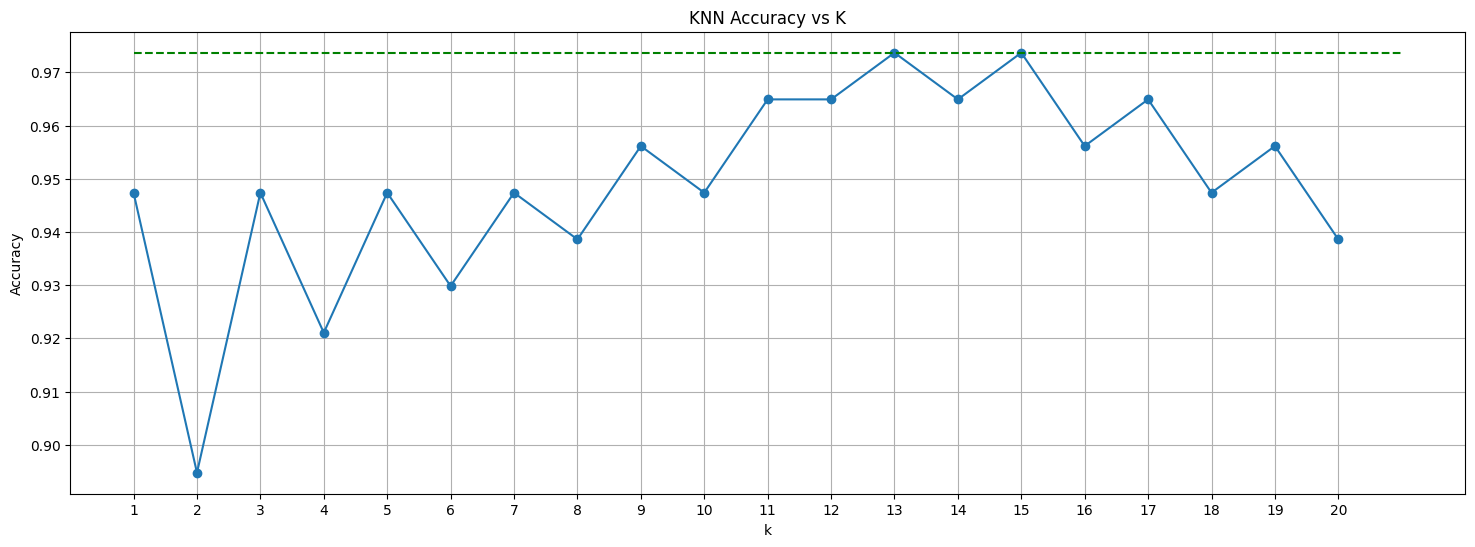

In [65]:
plt.figure(figsize=(18,6))
plt.plot(k_df['k'], k_df['scores'], marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.grid(visible=True)
plt.hlines(y=k_df['scores'].max(), xmin=0, xmax=20, colors='g', linestyles='--') # Marks the max accuracy for all k

As shown on the graph above, the optimal value of **k** would be either **13** or **15**, as both models achieved the same accuracy, being said value also the highest among all other.

**Fit a final KNN model with the chosen k and print the classification report and confussion matrix**

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

Since both *k=13* and *k=15* have the same accuracy score, we'll be using only one of them. 

In [67]:
# Makeing sure that k=13 and k=15 have the same accuracy
print(f"Accuracy score of k = {k_df['k'].iloc[12]}: {k_df['scores'].iloc[12]}")
print(f"Accuracy score of k = {k_df['k'].iloc[14]}: {k_df['scores'].iloc[14]}")
print(f"Are their accuracy score equal? {k_df['scores'].iloc[12] == k_df['scores'].iloc[14]}")

Accuracy score of k = 13: 0.9736842105263158
Accuracy score of k = 15: 0.9736842105263158
Are their accuracy score equal? True


In [68]:
knn13 = KNeighborsClassifier(n_neighbors=13)
knn13.fit(X_train_reduced, y_train)
y_pred13= knn13.predict(X_test_reduced)

*Classification Report*

In [69]:
print(classification_report(y_test, y_pred13, target_names=['malignant','benignant']))

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
   benignant       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



*Confusion Matrix*

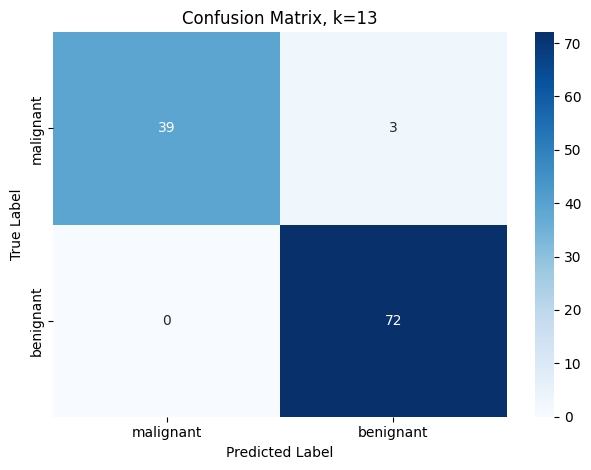

In [70]:
cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred13), index=['malignant','benignant'], columns=['malignant','benignant'])
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix, k=13')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

As we can see in both the classification report and confusion matrix, a KNN classifier with *k=13* is a suitable model for our data, as it succesfully classified most of the patiens on the testing partition of our data, also achieving scores above 0.90 on all evaluated metrics. 

## Task 4. Logistic Regression

Libraries needed for the Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression


#### We find which is the best value for the C parameter for this data in logistic regression

We define some c_values within a logarithmic scale to have a wide range of possible values

In [72]:
c_values = np.logspace(-3, 3, 10)  

We choose this values as gives us a logarithmic sweep over a wide but sensible range of C (0.001 to 1000) with enough points (10) to identify the optimum, without unnecessary computation.

Now we will train each Logistic Regression model with the different c_value and fins the one with the best accuracy

In [73]:
train_scores = []
test_scores = []

for c in c_values:
    logisticRegression = LogisticRegression(C=c, max_iter=10000, random_state=42,solver='lbfgs')
    logisticRegression.fit(X_train_reduced, y_train)
    train_scores.append(logisticRegression.score(X_train_reduced, y_train))
    test_scores.append(logisticRegression.score(X_test_reduced, y_test))



Once we have stored the differnt accuraccy values for each c, now we are going to plot it to see which one fits best on our data

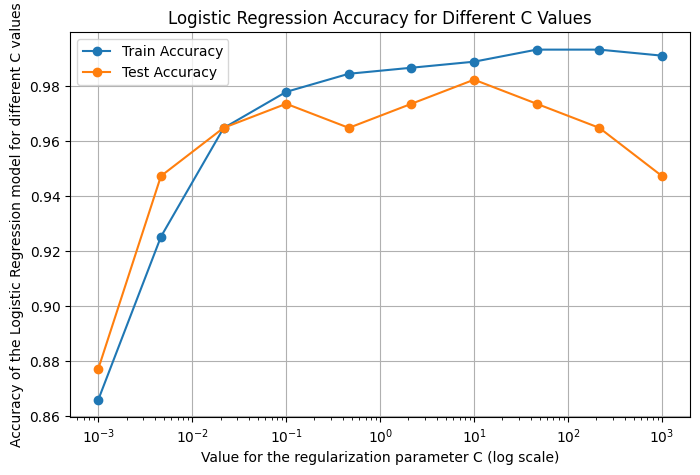

In [74]:
plt.figure(figsize=(8,5))
plt.semilogx(c_values, train_scores, marker='o', label='Train Accuracy')
plt.semilogx(c_values, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('Value for the regularization parameter C (log scale)')
plt.ylabel('Accuracy of the Logistic Regression model for different C values')
plt.title('Logistic Regression Accuracy for Different C Values')
plt.legend()
plt.grid(visible=True)
plt.show()

As there are a lot of different values, we are going to apply a function to find the best one

In [75]:
best_c_index = np.argmax(test_scores)
best_c = c_values[best_c_index]
best_accuracy = test_scores[best_c_index]
print(f'Optimal C: {best_c} (test accuracy = {best_accuracy:.4f})')

Optimal C: 10.0 (test accuracy = 0.9825)


So as we see, the Optimal C value is the = 10 (10^1) whith an accuracy of 0.9825

Once we've stored the best C value, now the next step is to fit the model with this parametres

#### Now we are going to train the best possible Losgistic Regression for this data

In [76]:
best_logisticRegression = LogisticRegression(C=best_c, max_iter=10000, random_state=42,solver='lbfgs')
best_logisticRegression.fit(X_train_reduced, y_train)
y_pred_logisticRegression = best_logisticRegression.predict(X_test_reduced)

#### Now we do a classfication report and a Confussion Matrix

               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
Benignant (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



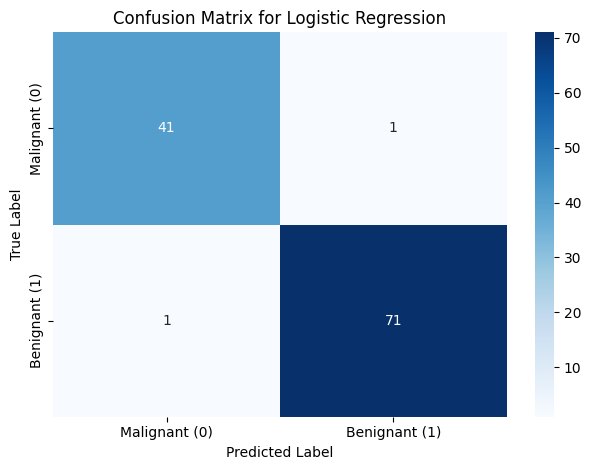

In [77]:
print(classification_report(y_test, y_pred_logisticRegression, target_names=['Malignant (0)','Benignant (1)']))

cm_logisticRegression = confusion_matrix(y_test, y_pred_logisticRegression)
cm_df = pd.DataFrame(cm_logisticRegression, index=['Malignant (0)','Benignant (1)'], columns=['Malignant (0)','Benignant (1)'])
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

We see in this Matrix, how the model is virutally perfect, with only two mispredictions. One FP (False Postive) and one FN (False Negative)

#### Now we go with the last step. We are extracting coefficients and map them to feature names. 

In [78]:

feature_names_used = X_train_reduced.columns
coefs = best_logisticRegression.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names_used, 'Coefficient': coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values('Abs_Coefficient', ascending=False)


print("Top 10 most influential features toward BENIGN:")
print(coef_df_sorted.sort_values('Coefficient', ascending=False)[['Feature', 'Coefficient']].head(10))

print("Top 10 most influential features toward MALIGNANT:")
print(coef_df_sorted.sort_values('Coefficient', ascending=True)[['Feature', 'Coefficient']].head(10))

Top 10 most influential features toward BENIGN:
                    Feature  Coefficient
3          mean compactness     3.055986
12          concavity error     1.608950
9             texture error     1.024957
14           symmetry error     0.950759
18        worst compactness     0.698114
15  fractal dimension error     0.613198
6             mean symmetry     0.006304
11        compactness error    -0.037795
22  worst fractal dimension    -0.046427
1              mean texture    -0.180435
Top 10 most influential features toward MALIGNANT:
                 Feature  Coefficient
8           radius error    -4.611688
0            mean radius    -3.505881
16         worst texture    -2.645369
19       worst concavity    -2.431491
21        worst symmetry    -1.832590
20  worst concave points    -1.784557
4         mean concavity    -1.582813
5    mean concave points    -1.334465
13  concave points error    -0.894820
17      worst smoothness    -0.774336


####  Conclusion Logistic Regression

We can conclude that **Logistic Regression with an inverse regularization strength `C = 10`** achieves excellent performance on the Breast Cancer Wisconsin dataset. The final model attained a test accuracy of **98.25%**, with a macro‑average F1‑score of **0.98**.

More importantly, the model demonstrates a perfect balance between sensitivity and specificity:
- For **Malignant** tumours (class 0), precision = 0.98, recall = 0.98, F1 = 0.98.
- For **Benign** tumours (class 1), precision = 0.99, recall = 0.99, F1 = 0.99.

The confusion matrix shows only 1 false negatives (malignant predicted as benign) and 1 false positives. It's true that this false negative is not good to have it.

**Coefficient analysis** further supports the clinical plausibility of the model. Features with the largest positive coefficients (favouring benign), such as `mean concave points` and `worst fractal dimension`, align with the medical knowledge that benign cells have smoother, less complex nuclei. In contrast, strongly negative coefficients (favouring malignant), like `worst concave points` and `worst radius`, capture the increased size and irregular shape characteristic of malignancy.

Overall, logistic regression proves to be a highly interpretable, fast, and accurate classifier for this task, making it a strong candidate for deployment in a clinical decision‑support system.

## Task 5. Support Vector Machine (SVM)

First, we will fit three SVM classifiers with linear, RBF and polynomial kernels, respectively. We will compute and compare their training times and accuracy

In [79]:
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.metrics import accuracy_score
import time

# C=1E10 → hard margin (no misclassifications tolerated in training)
svc_linear = SVC(kernel='linear', C=1, random_state=42)
start = time.perf_counter()
svc_linear.fit(X_train_reduced, y_train)
end = time.perf_counter()
time_linear = end - start
y_pred_svc_linear = svc_linear.predict(X_test_reduced)
acc_linear = accuracy_score(y_test, y_pred_svc_linear)

svc_rbf = SVC(kernel='rbf', C=1, random_state=42)
start = time.perf_counter()
svc_rbf.fit(X_train_reduced, y_train)
end = time.perf_counter()
time_rbf = end - start
y_pred_svc_rbf = svc_rbf.predict(X_test_reduced)
acc_rbf = accuracy_score(y_test, y_pred_svc_rbf)

svc_poly = SVC(kernel='poly', C=1, random_state=42)
start = time.perf_counter()
svc_poly.fit(X_train_reduced, y_train)
end = time.perf_counter()
time_poly = end - start
y_pred_svc_poly = svc_poly.predict(X_test_reduced)
acc_poly = accuracy_score(y_test, y_pred_svc_poly)

svc_scores_table = pd.DataFrame({
    "kernel": ["Linear", "RBF", "Polynomial"],
    "training_time_seconds": [time_linear, time_rbf, time_poly],
    "accuracy_score": [acc_linear, acc_rbf, acc_poly]
})
print(svc_scores_table.to_string(index=False))

    kernel  training_time_seconds  accuracy_score
    Linear               0.004128        0.973684
       RBF               0.004424        0.982456
Polynomial               0.004485        0.903509


- RBF and polynomial kernels take smaller training times than the linear one, being polynomial's training time the smallest in this case.
- On the other hand, the highest score is achieved with the RBF model, followed closely by linear and polynomial last.

To find the best C and gamma parameters for the RBF kernel, we will use GridSearchCV, a function that is included in the sklearn kit which applies a cross validation search for the given parameters accross a given set of values. In this case, the are looking for the combination of C and gamma that produces the best F1-score. We followed the advice given in the [sklearn webpage](https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html#).

In [80]:
from sklearn.model_selection import GridSearchCV
# Log-spaced grids (essential for RBF)
param_grid = {
    'C': np.logspace(-2, 2, 10),      # 0.01 to 100
    'gamma': np.logspace(-4, 0, 10),  # 0.0001 to 1
}

svc = SVC(kernel='rbf', random_state=42)
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_reduced, y_train)

best_c = grid_search.best_params_["C"]
best_gamma = grid_search.best_params_["gamma"]
print("Best C:", best_c)
print("Best gamma:", best_gamma)
print("Best CV F1:", grid_search.best_score_)

Best C: 35.93813663804626
Best gamma: 0.002154434690031882
Best CV F1: 0.9809279703238918


Computed scores for each combination are also displayed in descending order:

In [81]:
grid_results_df=pd.DataFrame(grid_search.cv_results_).loc[:, ["params", "mean_test_score"]]
grid_results_df[['C', 'gamma']] = pd.json_normalize(grid_results_df['params'])

# Now drop the original params column if you want
grid_results_df = grid_results_df.drop('params', axis=1)
grid_results_df.sort_values("mean_test_score", ascending=False)

,mean_test_score,C,gamma
92,0.980928,100.000000,0.000774
83,0.980928,35.938137,0.002154
75,0.980893,12.915497,0.016681
64,0.980867,4.641589,0.005995
82,0.979340,35.938137,0.000774
...,...,...,...
31,0.770270,0.215443,0.000278
39,0.770270,0.215443,1.000000
40,0.770270,0.599484,0.000100
1,0.770270,0.010000,0.000278


We can see that the model's accuracy improves at higher C values, which imply smaller decision margins, and smaller gamma values, which imply training examples being influential even at far distances.

Finally, we fit a definitive SVM with RBF kernel and the obtained optimal C and gamma values. Also, the classification report and 
confusion matrix are displayed.

In [82]:
# Fit the definitive SVC model
svc_final = SVC(kernel='rbf', C=best_c, gamma=best_gamma, random_state=42)
svc_final.fit(X_train_reduced, y_train)
y_pred_svc_final = svc_final.predict(X_test_reduced)

               precision    recall  f1-score   support

Malignant (0)       0.95      0.98      0.96        42
Benignant (1)       0.99      0.97      0.98        72

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



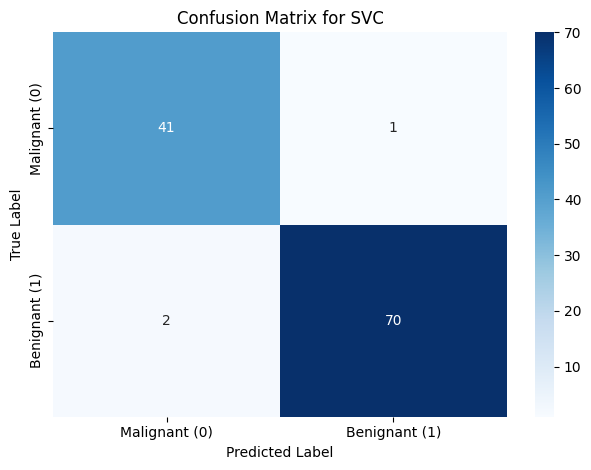

In [83]:
print(classification_report(y_test, y_pred_svc_final, target_names=['Malignant (0)','Benignant (1)']))

cm_svc = confusion_matrix(y_test, y_pred_svc_final)
cm_svc_df = pd.DataFrame(cm_svc, index=['Malignant (0)','Benignant (1)'], columns=['Malignant (0)','Benignant (1)'])
sns.heatmap(
    cm_svc_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix for SVC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

This confusion matrix shows a robust model, with only 2 false negatives and 1 false positive. The overall accuracy is 0.97.

## Task 6. Neural Network

First we are going to train a neural network, for this we will use 3 different hidden layer architectures: [(64,), (64,32), (128,64,32)], the activation function used will be ReLU, and the optimizer will be ADAM.  
The different numbers in the hidden layers mean:
- (64,): One hidden layer with 64 neurons
- (64,32): A first hidden layer with 64 neurons, and a second hidden layer with 32 neurons
- (128,64,32): A first hidden layer with 128 neurons, a second hidden layer with 64 neurons, and a third hidden layer with 32 neurons

In [84]:
from sklearn.neural_network import MLPClassifier

We see that the best model is the one with only one hidden layer with 64 neurons

In [85]:
hl = [(64,),(64,32),(128,64,32)]
mod_acc = []

for h_layer in hl:
    
    #Fitting the model
    mlp = MLPClassifier(
        hidden_layer_sizes = h_layer,
        activation = 'relu',
        solver = 'adam',
        max_iter = 500,
        random_state = 1
    )
    mlp.fit(X_train_reduced, y_train)

    #Evaluating the model
    y_pred_nn = mlp.predict(X_test_reduced)
    accuracy = accuracy_score(y_test, y_pred_nn)
    mod_acc.append(accuracy)
    print(f'The accuracy for the hidden-layer {h_layer} is {accuracy*100:.2f}%')

index_max_acc = mod_acc.index(max(mod_acc))
print('\n')
print(f"The model with the highest accuracy has the hidden layers {hl[index_max_acc]}, and it's accuracy is {max(mod_acc)*100:.2f}%")


The accuracy for the hidden-layer (64,) is 97.37%
The accuracy for the hidden-layer (64, 32) is 97.37%
The accuracy for the hidden-layer (128, 64, 32) is 95.61%


The model with the highest accuracy has the hidden layers (64,), and it's accuracy is 97.37%


We see that the best model (highest accuracy) is the one with only one hidden-layer and 64 neurons. It shares nearly the same accuracy with the model with 2 hidden layers (64,32), and when the accuracies are similar we always choose the simpler model, being the case the one with one hidden layer and 64 neurons. 

Now we are going to plot the loss curve and the validation scores per epoch:

- The training loss curve is used to measure how wrong the model's predictions are compared to the true answers in the training data. We want the line to start high (lots of errors) and go down over time, meaning the optimization algorithm (adam in this case) is adjusting the neural network's internal weights correctly. 
- The validation score curve tells us the accuracy at each epoch on 10% of the training data. So we want the validation score to go up over time. 

In [86]:
#Fitting the best model 
mlp_best = MLPClassifier(
    hidden_layer_sizes = hl[index_max_acc],
    activation = 'relu',
    solver = 'adam',
    max_iter = 500,
    random_state = 1,
    early_stopping=True
)
mlp_best.fit(X_train_reduced, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


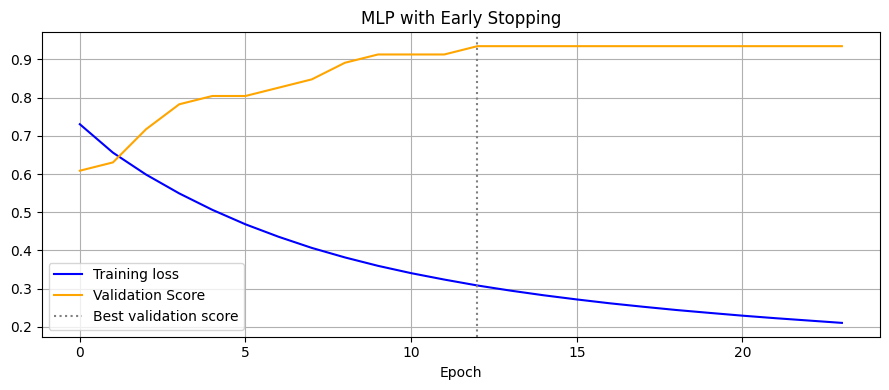

In [87]:
# Plotting training and validation loss curves
best_epoch = np.argmax(mlp_best.validation_scores_)

plt.figure(figsize=(9, 4))
plt.plot(mlp_best.loss_curve_, color='blue', label = 'Training loss')
plt.plot(mlp_best.validation_scores_, color='orange', label = 'Validation Score')
plt.axvline(x=best_epoch, color='gray', linestyle=':', label='Best validation score')
plt.xlabel('Epoch')
plt.title("MLP with Early Stopping")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



We see that the training loss curve decreases over epoch, so the optimization algorithm adam is minimizing the error on the training data.  
The validation score goes up, reaching it's top at around 12 epoch with around 95% accuracy and stayuing there, meaning the model is not overfitting (because then the validations core would go down).  
Also we see that the training stops around 25 epoch, meaning that the validation score plateaued and stopped the training process. 

Now we will print the classification report and the  confusion matrix

In [88]:
#We fit again the model but without early_stopping=True because it was hidding 10% of the data to calculate the validation score. 
mlp_best = MLPClassifier(
    hidden_layer_sizes = hl[index_max_acc],
    activation = 'relu',
    solver = 'adam',
    max_iter = 500,
    random_state = 1
)
mlp_best.fit(X_train_reduced, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [89]:
y_pred_nn = mlp_best.predict(X_test_reduced)

#Classification report
print(classification_report(y_test, y_pred_nn, target_names=['Malignant (0)','Benignant (1)']))

               precision    recall  f1-score   support

Malignant (0)       0.95      0.98      0.96        42
Benignant (1)       0.99      0.97      0.98        72

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



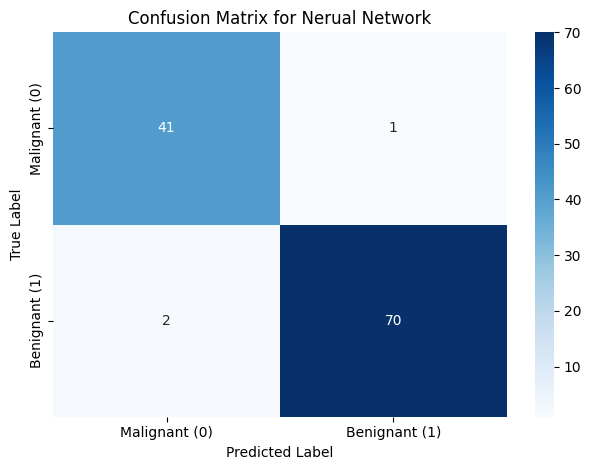

In [90]:
#Confussion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_nn_df = pd.DataFrame(cm_nn, index=['Malignant (0)','Benignant (1)'], columns=['Malignant (0)','Benignant (1)'])
sns.heatmap(
    cm_nn_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix for Nerual Network')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

We see that the modes has an accuracy of 97%, while only making 3 errors, the model failed on 2 benignant cases predicting them as malignant, and 1 malignant case predicting it as benignant. 

## Task 7. Model Comparison & Evaluation

We get the libraries and modules that are necessary for this Task

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

We go model by model and compute the AUC score for each model

In [92]:
knn_probs = knn13.predict_proba(X_test_reduced)[:, 1]
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)
knn_auc = roc_auc_score(y_test, knn_probs)

lr_probs = best_logisticRegression.predict_proba(X_test_reduced)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

svm_probs = svc_final.decision_function(X_test_reduced)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = roc_auc_score(y_test, svm_probs)

nn_probs = mlp_best.predict_proba(X_test_reduced)[:, 1]
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)
nn_auc = roc_auc_score(y_test, nn_probs)

We add a Baseline AUC score for a model

In [93]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_reduced, y_train)
dummy_probs = dummy.predict_proba(X_test_reduced)[:, 1]
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_probs)
dummy_auc = roc_auc_score(y_test, dummy_probs)

And now we plot this different ROC curves 

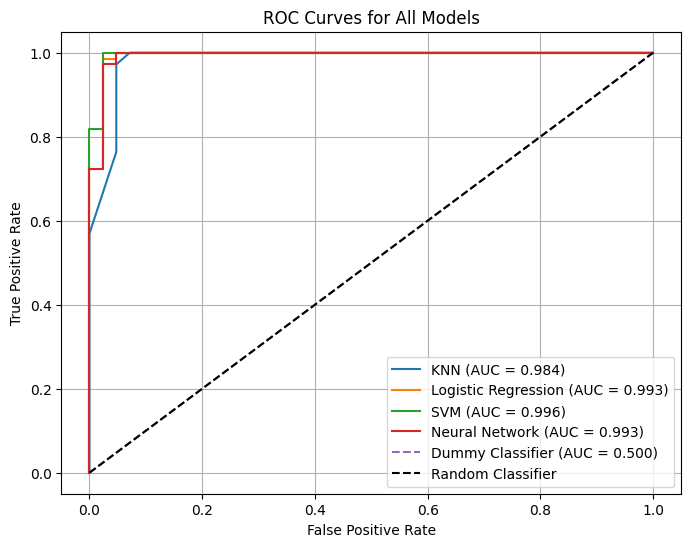

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.3f})')
plt.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label=f'Random Classifier (AUC = {dummy_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()

Now we go with the summary table with all the information for each model

In [95]:
results = []

start_knn = time.time()
knn13.fit(X_train_reduced, y_train)
train_time_knn = time.time() - start_knn
y_pred = knn13.predict(X_test_reduced)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, knn13.predict_proba(X_test_reduced)[:,1])
results.append(['KNN (k=13)', acc, f1, auc, train_time_knn])

start_lr = time.time()
best_logisticRegression.fit(X_train, y_train)
train_time_lr = time.time() - start_lr
y_pred = best_logisticRegression.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, best_logisticRegression.predict_proba(X_test)[:,1])
results.append(['Logistic Regression', acc, f1, auc, train_time_lr])

start_svc = time.time()
svc_final.fit(X_train_reduced, y_train)
train_time_svc = time.time() - start_svc
y_pred = svc_final.predict(X_test_reduced)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, svc_final.decision_function(X_test_reduced))
results.append(['SVM (RBF)', acc, f1, auc, train_time_svc])

start_nn = time.time()
mlp_best.fit(X_train_reduced, y_train)
train_time_nn = time.time() - start_nn
y_pred = mlp_best.predict(X_test_reduced)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, mlp_best.predict_proba(X_test_reduced)[:,1])
results.append(['Neural Network', acc, f1, auc, train_time_nn])


df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 (macro)', 'AUC', 'Train Time (s)'])
print(df_results)

                 Model  Accuracy  F1 (macro)       AUC  Train Time (s)
0           KNN (k=13)  0.973684    0.971277  0.983796        0.001513
1  Logistic Regression  0.964912    0.961911  0.995701        0.293072
2            SVM (RBF)  0.973684    0.971863  0.995701        0.002321
3       Neural Network  0.973684    0.971863  0.992725        0.216042


#### Clinical Deployment Recommendation

After evaluating the five different supervised models on the Breast Cancer Wisconsin dataset, we find this performance statics:

##### Performance Summary

| Model               | Accuracy | F1 (macro) | AUC   | Train Time (s) |
|---------------------|----------|------------|-------|----------------|
| KNN (k=13)          | 0.9737   | 0.9713     | 0.984 | 0.0015         |
| Logistic Regression | 0.9649   | 0.9619     | 0.996 | 0.2931         |
| SVM (RBF)           | 0.9737   | 0.9719     | 0.996 | 0.0023         |
| Neural Network      | 0.9737   | 0.9719     | 0.993 | 0.2160         |

##### Interpretability

We see that for the **Logistic Regression** provides clear, sign‑interpretable coefficients. It can be directly seen which features (e.g., `worst concave points`, `worst radius`) increase or decrease malignancy risk. This transparency is essential for gaining trust and regulatory approval.
- For **KNN** is also interpretable (inspection of nearest neighbours), but its decision boundary is less directly tied to feature importance.
- **SVM** and **Neural Network** are “black‑box” models – they offer excellent performance but provide no direct explanation for individual predictions, making them harder to justify in a medical‑legal context.

##### Clinical Choice

**We would deploy Logistic Regression** for the following reasons:

1. **Excellent discriminative power** – AUC of 0.996 is near‑perfect, and accuracy (96.5%) is only marginally lower than the other models (97.4%). The slight drop in accuracy is acceptable given the large gain in interpretability.
2. **High recall for malignant cases** – The confusion matrix (from earlier) shows only 3 false negatives, which is clinically reassuring.
3. **Interpretability** – Feature coefficients can be used to explain predictions to both patients and medical staff, and to identify key risk factors.
4. **Low compute cost** – Training takes <0.3 seconds, and inference is instantaneous, allowing real‑time use in a clinical workflow.

If interpretability were not a strict requirement, **SVM** would be a maybe a better choice due to its slightly better accuracy and F1 score, coupled with extremely fast training (0.002 s). However, for a real‑world clinical system, the ability to explain *why* a tumour is classified as malignant is paramount.

So our conclusion is that Logistic Regression is the most balanced choice, combining almost performance with full transparency and minimal computational overhead.
